In [157]:
import h3ppy
import pysynphot as S
import wget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm as lognorm
import numpy as np
import pandas as pd
import os
import scipy
import scipy.io as sio
from scipy.io import readsav
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from pathlib import Path
import glob
plt.rcParams.update({'font.size': 16}) #make font on graphs big :)

In [ ]:
#______________________________________#
#general information needed (examples shown):


order = "4" #currently set up to handle "1", "4", and "3" (if 3 has been dealt with) in echelle setting 1
genpath = "Y:/obs_23/Keck_29Dec/spec" #directory where data files are being stored
            #expected path structure:
                #genpath/eXoX/data + wave cal
            #where eXoX is the echelle setting (usually 1 for standard Keck stuff) and order (currently using 1,3,4
            #need access to all orders to be reduced
#the final created "path" variable (determined by which order you're reducing) will be where files are saved (starspec, fluxcal, data, etc)

#additional files needed (path is within one of the order directories, just need the name and file type):
dark = '/nspec231230_0001_dark.fits.gz'
star = '/nspec231230_0026_star7Tri.fits.gz'
sky  = '/nspec231230_0044_sky.fits.gz'

#______________________________________#
#information for calibration:


#name to use to search for flat files:
flatname = [11,12,13,14,15,16,17,18,19,20] #what number frame the flats you want to use have

#name to use to search for star files:
starname = [26,27,28,29,30,31,32,33]

#link to seeing information:  http://mkwc.ifa.hawaii.edu/current/seeing/index.cgi
#if the auto-finding seeing info breaks (aka if they didn't take data) you can input the value by hand here, otherwise leave commented
#seeing = 0.65
#want to be able to apply percentage into slit from seeing to individual files - need to start that here

#for now, will just leave as a few arrays and type them in manually - hopefully be fully integrate into pipeline once kinks are worked out

perc_array = np.asarray([24, 32.48, 31.41, 28.81, 28.31, 29.68, 26.22, 31.12])


#choose the model for your star - chosen here is an A0V which should cover our stars
#different star types and their inputs can be found here in Table 2: 
#https://www.stsci.edu/hst/instrumentation/reference-data-for-calibration-and-tools/astronomical-catalogs/kurucz-1993-models
#model suite: 'k93models', effective temperature: 9520, metallicity: 0, gravity (log(g)): 4.14
Kurucz_model = S.Icat('k93models', 9520, 0, 4.14)

#K-band star magnitude from values on SIMBAD: http://simbad.u-strasbg.fr/simbad/
#star used here was 7 Tri
star_magnitude =  5.228 

#______________________________________#
#apply flux calibration to data:


#name to use to search for jupiter files:
jupname = "jup" #really just a word that only appears in this kind of file's name
#name to use to search for sky files:
skyname = "sky" #really just a word that only appears in this kind of file's name
#______________________________________#

In [ ]:
#update paths and stuff when changing the directory
#this sets all save & load directories based on order

if order == '1':
    ordername = "First"
    path = genpath + r"\e1o1"
    
    #you might need to check where the wavecal file is saved, but everything below this does not need to be changed
    wave_e1o1_list = sio.readsav(path + "/wavelength.sav", verbose=False, python_dict = True)
    wave_e1o1 = wave_e1o1_list['wavelength']
    wave_micron = wave_e1o1 #wavelength file in microns
    wave_ang = wave_e1o1*10000 #wavelength file in angstroms
    print(order)
    
elif order == '3':
    ordername = "Third"
    path = genpath + r"\e1o3" 
    
    wave_e1o3_list = sio.readsav(path + "/wavelength.sav", verbose=False, python_dict = True)
    wave_e1o3 = wave_e1o3_list['wavelength']
    wave_micron = wave_e1o3 #wavelength file in microns
    wave_ang = wave_e1o3*10000 #wavelength file in angstroms
    
    print(order)
    
elif order == '4':
    ordername = "Fourth"
    path = genpath + r"\e1o4"
    
    wave_e1o4_list = sio.readsav(path + "/wavelength.sav", verbose=False, python_dict = True)
    wave_e1o4 = wave_e1o4_list['wavelength']
    wave_micron = wave_e1o4 #wavelength in microns
    wave_ang = wave_e1o4*10000 #wavelength in angstroms
    
    print(order)
    


else:
    print("Error in detecting order")

In [ ]:
#open general fits files from data to pull information from header on setup
                #such as slit size, ccd pixels, etc
fitspath = path + dark 
fitsarray = fits.open(fitspath)
starpath = path + star 
stararray = fits.open(starpath)
skypath = path + sky
skyarray = fits.getdata(skypath)

In [ ]:
#function to correct individual files for the impact of coadds on the integration time
def coaddsint(path):
    
    arrlist = get_pkg_data_filename(path)
    start = fits.getdata(arrlist, ext=0)
    #print(np.max(start), np.min(start))
    
    fitsarr = fits.open(path)
    itime = fitsarr[0].header['TRUITIME'] #time integrated
    #print(itime)
    coadds = fitsarr[0].header['COADDS'] #number of integrations for a single file
    #print(coadds)
    time = itime * coadds #total time based on coadds
    #print(time)
    finalarr = start/time #convert file from counts to counts/sec for later flux calibration
    #print(np.max(finalarr), np.min(finalarr))
    
    return(finalarr)



flatFiles = glob.glob(path + "/*.fits") #search for all fits files in directory
flatarr = 0 #array to put all of the flats into

for flatfilename in flatFiles:
    for fname in flatname:
        zeronum = 4 - len(str(fname)) #formatting the name so it has the right # of preceding 0s - avoids calling the wrong file
        zeroes = "0" * zeronum
        if zeroes + str(fname) in flatfilename:
            print(flatfilename)
            flatcoadds = coaddsint(flatfilename) #run codds&int time  function on each file
            flatarr = flatcoadds + flatarr #add all flats together
            #print(np.max(flatarr), np.min(flatarr))
    flat = flatarr/len(flatname)
FmD = flat/np.max(flat)
FmD = FmD + (1 - np.median(FmD)) #normalize flat to 1


plt.plot(np.sum(FmD, axis = 1))
plt.title("FmD")
plt.xlabel("Slit Position")
plt.ylabel("Photon Counts")
plt.show()

newpath = path + r"\cal" #create cal path if one doesn't already exist; it should in the current file structure though
if not os.path.exists(newpath):
    os.makedirs(newpath)

np.save(path + r"\cal\FmD.npy", FmD) #save flat within cals folder

    
#stars
starFiles = glob.glob(path + "/*.fits") #search for all fits files in director
starlabel = 0
percentage_counter = 0

starA = []
starB = []
labels = []


for starfilename in starFiles:
    for sname in starname:
        zeronum = 4 - len(str(sname)) #formatting the name so it has the right # of preceding 0s - avoids calling the wrong file
        zeroes = "0" * zeronum
        if zeroes + str(sname) in starfilename: #specifically pull out any files with "star" in name
            fitshead = fits.open(starfilename)
            fitsarr = fits.getdata(starfilename)
            stardisc = fitshead[0].header['OBJECT'] #check name of star
            maxstar = (np.sum(fitsarr, axis = 1)).argmax() #find position of the trace on the slit
            
            if maxstar > (len(fitsarr))/2: #assign stars with peak in "bottom" of slit with "B"
                print(starfilename)
                starlabel = starlabel + 0.5
                star = coaddsint(starfilename)
                labels.append("B")
                starB.append(star)
                #locals()["starB"+str(int(starlabel+0.5))] = coaddsint(starfilename) #creates variable for each star
                print("Created starB"+str(int(starlabel+0.5))) #tells you name of all of the created star variables
                    
            elif maxstar < (len(fitsarr))/2: #assign stars with peak in "top" of slit with "A"
                print(starfilename)
                starlabel = starlabel + 0.5
                star = coaddsint(starfilename)
                labels.append("A")
                starA.append(star)
                #locals()["starA"+str(int(starlabel+0.5))] = coaddsint(starfilename) #creates variable for each star
                print("Created starA"+str(int(starlabel+0.5))) #tells you name of all of the created star variables
            else:
                print("Error in determining peak position")

starpairs = np.int64((len(starname))/2) #number of AB pairs - used for graphing below
print("Number of star pairs:" + str(starpairs))

#make array of star pair differences
stardifflist = []
for i in range(starpairs):
    stardiff = (starA[i] - starB[i]) / FmD #creating A-B star pairs
    stardifflist.append(stardiff)

In [ ]:
#a whole buncha plots showing the final A-B stars;
#just to check that everything looks as expected (2 peaks in each graph, one positive, one negative)
#and to make sure that the "peak finding" method works for the next step

crop = 20 #change the bounds for where the we are looking for the peaks with this - it crops off the edges of the slit

for i in range(starpairs):
    plt.figure(figsize=(16, 4))
    plt.plot(np.sum(stardifflist[i], axis = 1))
    plt.axvline(x = np.sum(stardifflist[i][crop:-crop], axis = 1).argmax()+crop, linestyle = ':',color = 'orange', linewidth = 1, 
           label = "Pos A: " + str(np.sum(stardifflist[i][crop:-crop], axis = 1).argmax()+crop))
    plt.axvline(x = np.sum(stardifflist[i][crop:-crop], axis = 1).argmin()+crop, linestyle = ':',color = 'red', linewidth = 1, 
           label = "Pos B: " + str(np.sum(stardifflist[i][crop:-crop], axis = 1).argmin()+crop))
    plt.axhline(y = 0, color = "black", linestyle = "--")
    plt.title("Difference Between Star A" + str(i) + " and B" + str(i))
    plt.legend()
    plt.xlabel("Slit Position")
    plt.ylabel("Counts/Sec")
    plt.show()

In [ ]:
peakwidth = 20
#function to pull out just the peaks of stars in a single A-B data frame
#stardiff: an A-B frame (so the max and min values within some range vertically
                                #should correspond to an A and B respectfully)
#width: the width of the peak (adds to each side of max/min) - 20 should be fine
                        #want some extra room to play with for gaussian fit

def pullstarpeaks(stardiff, width = peakwidth):
#eventually make the width automated via seeing/pixel scale
    
    Alist = []
    Blist = []
    
    ymax = np.sum(stardiff[crop:-crop], axis = 1).argmax() + crop #finds positive peak index from spectrum summed in wavelength
    ymin = np.sum(stardiff[crop:-crop], axis = 1).argmin() + crop #find negative peak index from spectrum summed in wavelength
    
    #print(ymax)
    #print(ymin)
    index = 0
    
    for i in range(len(stardiff[0])): #now finding each peak at those indexes for each position in wavelength
        index = index + 1
        
        Amaxlow = ymax-width
        Amaxhigh = ymax+width
        #print(stardiff[ymax, i])
        finalpeakA = stardiff[Amaxlow:Amaxhigh, i]
        Alist.append(finalpeakA)
       

        Bminlow = ymin-width
        Bminhigh = ymin+width
        finalpeakB = stardiff[Bminlow:Bminhigh, i]
        #print(stardiff[ymin, i])
        Blist.append(finalpeakB)
        

    return np.asarray(Alist),np.asarray(Blist)

In [ ]:
Apeakslist = np.zeros((len(wave_micron), 2*peakwidth))
Bpeakslist = np.zeros((len(wave_micron), 2*peakwidth))

print(perc_array)

for i in range(starpairs):

    allpeaks = pullstarpeaks(stardifflist[i])
    
    Apeakstemp = allpeaks[0] #isolate star peak from wider array
    index = [a for a, n in enumerate(labels) if n == 'A'][i] #find the index of the first A star in the label list
    Apeakstempperc = Apeakstemp / (perc_array[index]*10**(-2)) #pull that same index percentage "flux into the slit" to apply to the correct star
    print("Percentage for A" + str(i) + ": " + str(perc_array[index]))

    Bpeakstemp = allpeaks[1]
    index = [b for b, n in enumerate(labels) if n == 'B'][i] #find the index of the first A star in the label list
    Bpeakstempperc = Bpeakstemp / (perc_array[index]*10**(-2)) #pull that same index percentage "flux into the slit" to apply to the correct star
    print("Percentage for B" + str(i) + ": " + str(perc_array[index]))
    
    Apeakslist = Apeakslist + Apeakstempperc
    Bpeakslist = Bpeakslist + Bpeakstempperc
    
    

Apeaks = Apeakslist / starpairs
Bpeaks = Bpeakslist / starpairs

In [ ]:
#function to integrate area under the data
#data: peaks pulled from full data
#width: width of area to integrate; finds center of data then does +/- width
def integratedata(data, width):
    area = []

    for i in range(len(data)):
        peakindex = int(len(data[1])/2) #index of the gaussian peak
        
        #calulated area from data
        areadata = scipy.integrate.trapezoid(data[i][peakindex-width:peakindex+width+1],
                                           range(len(data[i][peakindex-width:peakindex+width+1])))
        
        if areadata <= 5:
            areadata = 5
        
        area.append(areadata)
    return area

In [ ]:
Aarea_int = integratedata(Apeaks, 20)

In [ ]:
Barea_int = integratedata(np.asarray(Bpeaks)*-1, 20)

In [ ]:
#here, C is the average starspec from the A and B peaks
#A and B can differ slightly depending on how well centered the star was on the slit
#fixes to come to try and include that difference via information from SCAM - currently in progress on March 3, 2025
Carea_int = (np.array(Aarea_int) + np.array(Barea_int))/2

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(wave_micron, Aarea_int, label = "A")
plt.plot(wave_micron, Barea_int, label = "B")
plt.plot(wave_micron, Carea_int, color='black', label = 'C')

plt.title(ordername + " Order Starspec")
plt.xlabel("Microns")
plt.ylabel("Counts/Sec")
plt.ylim(200,850)
plt.legend()
plt.show()

In [ ]:
#final units here are counts/sec
#choose which starspec to save based on above figure and how the peaks looked earlier on
#default is average
print("Decide which starspec to use: A, B, C (avg A&B)")
starspec = np.array(Carea_int)
#starspec = np.array(Aarea_int)
#starspec = np.array(Barea_int)

#automatically chooses where to save starspec based on the order being reduced
if order == '1':
    np.save(path + r"\starspec1_perc.npy", starspec)

elif order == '3':
    np.save(path + r"\starspec3_perc.npy", starspec)

elif order == '4':
    np.save(path + r"\starspec4_perc.npy", starspec)

else:
    print("Error detecting chosen order")

In [ ]:
#this section uses pysynphot & the Kurucz star atlas
#load in star spectrum: 7Tri #THING TO UPDATE WITH NEW DATA (what star was used)
# A0V kp00_9500[g40] 
#need T_eff = 9520, metallicity = 0, log(g) = 4.14
sp = Kurucz_model #this is the kurucz entry for an A0V star
#sp = S.Icat('k93models', 10000, 0, 4.14)


#configure star spectrum into something the bandpass can normalize
Kurucz = S.ArraySpectrum(sp.wave, sp.flux)

In [ ]:
vega_flux = 4.07e-10 #specific for K-band
#UPDATE m_star from values on SIMBAD
#star used here was 7 Tri
#print("Update K-band star magnitude with SIMBAD")
#http://simbad.u-strasbg.fr/simbad/
m_star =  star_magnitude #THING TO UPDATE WITH NEW DATA (magnitude of observed star within the specific wavelength range being used)
starflux = vega_flux * (10**(-0.4*m_star)) 
print(starflux)


#W/m^2/micron * 10^-1 for the conversion of um, m^2, and W, to AA, cm^2, erg/s
constant = starflux*10**(-1)


#center of band being used; in this case, K-band
band_wl = 2.2 #microns
band_ang = 22000 #angstroms

In [ ]:
#find index of center of band for normalization at center of order band
#normalize to center of K-band (where the star mag is from)
number = np.abs(Kurucz.wave - band_ang).argmin()
#print(number)
print(Kurucz.wave[number])


#normalize the model spectrum to the magnitude of the star
starnorm = constant/Kurucz.flux[number]
Kurucz_band = starnorm*Kurucz.flux


#some checks to make sure things are working correctly:
print("Value model is being normalized to: " + str(starnorm))

if np.abs(Kurucz_band - constant).argmin() == number:
    print("Correct Normalization")
else:
    print("Incorrect Normalization")
    
    
## model is in units of erg/s/cm^2/AA, want it to be W/m^2/micron
Kurucz_W = (Kurucz_band)*10

#look at region of star model being used; mostly to see if there are any interesting absorption features
maxy = Kurucz_W[np.abs(Kurucz.wave - np.max(wave_ang)).argmin()]
miny = Kurucz_W[np.abs(Kurucz.wave - np.min(wave_ang)).argmin()]
    
plt.figure(figsize=(16, 4))
plt.plot(Kurucz.wave, Kurucz_W)
#plt.plot(wave_ang, Ibb, color = "black", label = "bb")
plt.xlim(np.min(wave_ang)-np.min(wave_ang)*0.01, np.max(wave_ang)+np.max(wave_ang)*0.01)
plt.ylim(miny-0.1*miny, maxy+0.12*maxy)
#plt.ylim(3.2e-13, 3.9e-13)

plt.axvline(x = np.min(wave_ang), label = "Lower Boundary - Wavelength", color = "r")
plt.axvline(x = np.max(wave_ang), label = "Upper Boundary - Wavelength", color = "g")
plt.legend()
plt.show()

In [ ]:
#interpolate Kurucz spectrum to calibrator wavelengths so they are the same size & at same wavelengths
final_constant = np.interp(wave_ang, Kurucz.wave, Kurucz_W)
#print(final_constant)

if len(final_constant) == len(wave_ang):
    print("Correct Interpolation")
else:
    print("Incorrect Interpolation")

In [ ]:
fluxcal = final_constant/starspec

In [ ]:
# Need to convert the instrument FOV to units of sterradian
# The pixel width is 0.098 arcsec with a slit width of 0.288 arcsec (NIRSPEC High resolution echelle)
# Note - there are 4.2545e10 arceconds in a sterradian

#final units here are now W/m^2/micron/str/count

platescale = fitsarray[0].header['PSCALE']
slitwidth = float(fitsarray[0].header['SLITNAME'][0:5])
print("Plate Scale: " + str(platescale) + "''/pixel" + ", Slit Width: " + str(slitwidth)+ "''")


fluxcal_str = fluxcal * 4.2545e10 / (platescale * slitwidth)

#save final fluxcal
if order == "1":
    np.save(path + '/fluxcal1_str_perc.npy', fluxcal_str)
elif order == "3":
    np.save(path + '/fluxcal3_str_perc.npy', fluxcal_str)
elif order == "4":
    np.save(path + '/fluxcal4_str_perc.npy', fluxcal_str)
else:
    print("Error detecting chosen order")

print("Flux Calibration Successfully Saved as '" + path + "/fluxcal"+ order +"_str_perc.npy'")

In [ ]:
#load final fluxcal
if order == "1":
    fluxcal_str = np.load(path + '/fluxcal1_str_perc.npy')
elif order == "3":
    fluxcal_str = np.load(path + '/fluxcal3_str_perc.npy')
elif order == "4":
    fluxcal_str = np.load(path + '/fluxcal4_str_perc.npy')
else:
    print("Error detecting chosen order")

In [ ]:
#comparing fluxcals just to see differences
plt.figure(figsize=(16, 6))
plt.plot(wave_micron, fluxcal_str)


plt.title(ordername + " Order Flux Calibration")
plt.ylabel("W*sec/m^2/micron/str/count")
plt.xlabel("Microns")
#plt.legend()
plt.ylim(0.00005,0.0008)
plt.show()

In [ ]:
#function to apply take difference between A and B frames and then apply flat
def ABFlat(A,B,Flat):
    C = (A - B)/(Flat)
    return C

newpath = path + "/Reduction Files" #creates new directory if it doesn't already exist
if not os.path.exists(newpath):
    os.makedirs(newpath)


#sky frames
skyFiles = glob.glob(path + "/*.fits.gz") #search for all fits files in directory
skytime_list = []
skyname_list = []
skylabel = 0

for skyfilename in skyFiles:
    if skyname in skyfilename and "BAD" not in skyfilename:
        skyfitsarr = fits.open(skyfilename)
        skytime = skyfitsarr[0].header['MJD'] #find the time the sky frame was taken
        #print(f_name, skytime)
        skytime_list.append(skytime)
        skyname_list.append(skyfilename)

        
#jupiter frames
jupFiles = glob.glob(path + "/*.fits.gz") #search for all fits files in directory
jupcount = 0
jupframes = []

for jupfilename in jupFiles:
    if jupname in jupfilename and skyname not in jupfilename and "BAD" not in jupfilename:
        jupfitsarr = fits.open(jupfilename)
        f_name, f_ext = os.path.splitext(os.path.join(path, jupfilename))
        print("Jupiter File Name: " + str(jupfilename))
        juptime = jupfitsarr[0].header['MJD'] #find the time the Jup fram was taken
        
        index = np.abs(np.asarray(skytime_list) - juptime).argmin()
        starfitsarr = fits.open(skyname_list[index])
        print("Sky File Name: " + str(skyname_list[index]))
        jupcoadds = coaddsint(jupfilename) #do the coadd corrections
        skycoadds = coaddsint(skyname_list[index])
        jup = ABFlat(jupcoadds,skycoadds,FmD) #apply the flat
        
        
         #saves the sky-subtracted, flat-corrected file with its original file name (continuity)
        np.save(newpath + "/" + Path(f_name).stem + "_e1o" + order, jup)

In [ ]:
#this is literally just to look at a file and make sure it looks okay
your_path = path + r"\Reduction Files"
files = os.listdir(your_path)
index = 0
for file in files:
    if os.path.isfile(os.path.join(your_path, file)):
        index = index + 1
        
        if index == 5: #can put any number here to pull a different file (smaller than # of jup files)
            jup = np.load(os.path.join(your_path, file))
            print(os.path.join(your_path, file))


#num is slit position; usually chosen to be in auroral region for clearer h3+ emissions
num = 20

plt.figure(figsize=(16, 12))
plt.imshow(jup, cmap='terrain', norm = lognorm())
plt.axhline(y = num, color = 'red', label = "Position of " + str(num))
plt.xlabel("Wavelength position (pixels) - some equivalence to microns")
plt.ylabel("Slit Position")
plt.legend()
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(wave_micron, jup[num])
plt.title(ordername + " Order: Flat Fielded & Sky Subtracted")
plt.xlabel("Microns")
plt.ylabel("Counts/Sec")
#check lines to be used for h3ppy fits
if order == "1":
    plt.axvline(x = 3.95299, color = 'Red', label = "Q(1,0)", linewidth = 0.8, linestyle = ":")

    plt.fill_between(wave_micron[1625:1675], -1, 100, color = "magenta", alpha = 0.1)
elif order ==  "4":
    plt.axvline(x = 3.41488, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,1)")
    plt.axvline(x = 3.42071, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,2)")
    plt.axvline(x = 3.45475, color = "r", linewidth = 0.8, linestyle = ":", label = "R(4,3)")

    plt.fill_between(wave_micron[1825:1875], -1, 100, color = "magenta", alpha = 0.1)
plt.legend()
plt.show()

In [ ]:
#apply fluxcal to all data & save

newpath = path + "/Reduction Files/fcal data" #make directory if it doesn't already exist
if not os.path.exists(newpath):
    os.makedirs(newpath)

if order == "1":
    bound1 = 1625
    bound2 = 1675
elif order == "4":
    bound1 = 1825
    bound2 = 1875
else:
    "Not order 1 or 4 - need to determine what appropriate bounds are"

index = 0 #literally just for picking a file to graph
your_path = path + "/Reduction Files"
files = os.listdir(your_path)
for file in files:
    if os.path.isfile(os.path.join(your_path, file)):
        f_name, f_ext = os.path.splitext(os.path.join(your_path, file)) #pull name of file
        jup = np.load(os.path.join(your_path, file))
        jup_final = jup * fluxcal_str #multiply by fluxcal
        for i in range(len(jup_final)):
            jup_final[i] = jup_final[i] - np.median(jup_final[i, bound1:bound2])
            
        index = index + 1
        
            
        np.save(
           path + "/Reduction Files/fcal data/" + Path(f_name).stem + "_final.npy", jup_final #save with original file name
               )
#plot file in directory to see before/after fluxcal
        if index == 3: #can change to any file you want, starting from 0
            num = 50 #slit position; usually chosen to be in auroral region
            
            plt.figure(figsize=(16, 4))
            plt.rcParams['axes.facecolor'] = 'black'
            
            plt.imshow(jup_final, norm=lognorm(), cmap = "terrain")
            plt.axhline(y = num)
            plt.show()
                        
            plt.figure(figsize=(16, 4))
            plt.rcParams['axes.facecolor'] = 'white'
            plt.plot(wave_micron,jup[num])
            plt.fill_between(wave_micron[bound1:bound2], -1, 100, color = "magenta", alpha = 0.1)
            if order == "1":
                plt.axvline(x = 3.95299, color = 'Red', label = "Q(1,0)", linewidth = 0.8, linestyle = ":")
            elif order ==  "4":
                plt.axvline(x = 3.41488, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,1)")
                plt.axvline(x = 3.42071, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,2)")
                plt.axvline(x = 3.45475, color = "r", linewidth = 0.8, linestyle = ":", label = "R(4,3)")
            plt.ylim(-10, 60)

            
            plt.xlabel("Microns")
            plt.ylabel("Arbitrary Flux Units")
            plt.title("Flat Fielded and Sky Subtracted Spectrum")
            plt.legend()
            plt.show()
                        
            plt.figure(figsize=(16, 4))
            plt.plot(wave_micron,jup_final[num])
            plt.fill_between(wave_micron[bound1:bound2], -1, 100, color = "magenta", alpha = 0.1)
            plt.axhline(y = 0, color = "black")
            if order == "1":
                plt.axvline(x = 3.95299, color = 'Red', label = "Q(1,0)", linewidth = 0.8, linestyle = ":")
                plt.ylim(-.001, .01)
            elif order ==  "4":
                plt.axvline(x = 3.41488, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,1)")
                plt.axvline(x = 3.42071, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,2)")
                plt.axvline(x = 3.45475, color = "r", linewidth = 0.8, linestyle = ":", label = "R(4,3)")
                plt.ylim(-.001, .01)
            
            plt.xlabel("Microns")
            plt.ylabel("W/m^2/micron/str")
            plt.title("Flux Calibrated Spectrum")
            plt.legend()
            plt.show()

In [ ]:
#moving to Slit Length Differences (Based on Order)

In [ ]:
#load in flat file and find the average value of the flat when its summed in the wavelength direction
sumsky = np.sum(skyarray, axis=1)
#flatsumavg = np.average(sumflat[40:-40])
skysumavg = np.median(sumsky)#only want the median of the portion in the middle
                                        #the edges are what we want to get rid of

In [ ]:
#define edge as where it drops more than 5%

edgeval = skysumavg - 0.05*skysumavg #find the y-value of the 5% drop
bounds_sky = int(len(sumsky)*0.1) #the middle of the array
frontedge = np.abs(sumsky[0:bounds_sky] - edgeval).argmin() #index of first "real" pixel

backedge = np.abs(sumsky[-1*bounds_sky:-1] - edgeval).argmin()+ len(sumsky) - bounds_sky #index of last "real" pixel

#correction if need to move by a pixel or two; trying to capture the first "decreased" pixel from mostly flat bit
if order == "1":
    frontedge += 1 #increase or decrease what the chosen pixels are, check them below in the plot
    backedge += - 0

elif order == "4":
    frontedge += 1
    backedge += - 1
    
#print("First pixel to keep:",frontedge)
#print("Last pixel to keep:",backedge)

In [ ]:
#visualization of median and boundary cutoffs on flat
plt.figure(figsize=(8, 8))
plt.plot(sumsky, "r")
plt.scatter(np.arange(len(sumsky)), sumsky, color = "r")

plt.title("Sky Frame Summed Along Wavelength Direction (Order " + order + ")")
plt.xlabel("Slit Position")
plt.ylabel("Summed Counts")


plt.axhline(y = skysumavg, color = 'y', label = "Median of points")
plt.scatter(frontedge, sumsky[frontedge], color = "black", marker = "_", s = 200, linewidth=3,
           label = "Calculated Boundary (5% Drop): [" + str(frontedge) + "," + str(backedge) + "]")
plt.scatter(backedge, sumsky[backedge], color = "black", marker = "_", s = 200, linewidth=3)


plt.axvline(x = bounds_sky) #median bounds plotted for reference but not explicitly labeled
plt.axvline(x = len(sumsky) - bounds_sky)
plt.legend()

In [ ]:
#find better way to pull from fits header?
print("CHECK TO MAKE SURE SLIT LENGTH IS CORRECT")
print("Slit size from fits header: " + str(fitsarray[0].header['SLITNAME']))

if fitsarray[0].header['SLITNAME'] == "0.288x24" or fitsarray[0].header['SLITNAME'] == "0.432x24":
    slitlength = 24 #arcsec
    
else:
    print("Slit Length is not 0.288x24 or 0.432x24 arcsec, input slit length manually")
    slitlength = 24 #If slit length is not 24, change
    
    
print("Slit length inputted: " + str(slitlength))
platescale = fitsarray[0].header['PSCALE']

truepixels = int(slitlength/platescale) #should be 186 pixels for 24 arcsec slit with NIRSPEC post-2019 upgrade
print("The resulting array length is" , truepixels)

In [ ]:
#interpolate the data array to the length of the "real" array
def interparray(data, length):
    slitarray = np.linspace(0, 1, num=length) #create array of values from 0 to 1 the same size as final array
    comparisonarray = np.linspace(0, 1, num=int(len(data[:,1]))) #create array of values from 0 to 1 size of original array
       
    #done like this because we need some comparison to be able to interpolate values to
    #two arrays of different sizes but covering the same span of data lets us do that
    
    arr = []
    for i in range(len(data[1,:])):
        interp = np.interp(slitarray, comparisonarray, data[:,i]) #interpolate array
        arr.append(interp)
       
    return np.array(arr)

In [ ]:
index = 0
your_path = path + "/Reduction Files/fcal data"
files = os.listdir(your_path)
for file in files:
    if os.path.isfile(os.path.join(your_path, file)):
        f_name, f_ext = os.path.splitext(os.path.join(your_path, file))
        jup = np.load(os.path.join(your_path, file))
        jup_crop = jup[frontedge:backedge + 1] #crop frames down to size, python uses (frontedge, backedge], so we need to include the last index
        jup_interp = interparray(jup_crop, truepixels).T #interpolate to "true" slit size (186)
        index = index + 1
        
        newpath = path + "/Reduction Files/fcal data/interp"
        if not os.path.exists(newpath):
            os.makedirs(newpath)
        
        np.save(
            path + "/Reduction Files/fcal data/interp/" + Path(f_name).stem + "_interp.npy", jup_interp
                )

In [ ]:
#plot one of the saved data files


index = 0 
your_path = path + "/Reduction Files/fcal data/interp/"
files = os.listdir(your_path)
for file in files:
    if os.path.isfile(os.path.join(your_path, file)):
        jup = np.load(os.path.join(your_path, file), allow_pickle = True)
        index = index + 1
        
        if index == 69: #change this to plot a different file
        
            print(os.path.join(your_path, file))
            num1 = 50
            num2 = 160

            plt.figure(figsize=(16, 4))
            plt.plot(wave_micron, jup[num1]-0.1, label = "1 (shifted down 0.1)")
            plt.plot(wave_micron, jup[num2], label = "2")
            plt.xlabel("Microns")
            plt.ylabel("W/m^2/micron/str")
            plt.title("Flux Calibrated Spectrum")
            #plt.ylim(-.01, .06)
            
            if order == "1":
                plt.axvline(x = 3.953, color = 'Red', label = "Q(1,0)", linewidth = 0.8, linestyle = ":")
            elif order ==  "4":
                plt.axvline(x = 3.415, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,1)")
                plt.axvline(x = 3.421, color = "r", linewidth = 0.8, linestyle = ":", label = "R(3,2)")
                plt.axvline(x = 3.455, color = "r", linewidth = 0.8, linestyle = ":", label = "R(4,3), R(4,4)")
                
            plt.legend(loc = "lower right")
            plt.show()
            
            plt.figure(figsize=(16, 4))
            plt.imshow(jup, norm = lognorm(), cmap = "terrain")
            plt.axhline(y = num1, label = "1", color = "tab:blue")
            plt.axhline(y = num2, label = "2", color = "tab:orange")
            plt.legend()
            plt.show()

In [158]:
import math

#from smith&smith1972 - functionally the only important variables are:
#Jupiter's radius (which shouldn't change) 
#the height of the H3+ layer

#the thickness of the H3+ layer bring probed doesn't seem to affect things as strongly

In [159]:
#this is what I started with
Re = 71492 #km
thickness = 800 #km
H = 700 #km

#current version
#testing new values
Re = 66854 #km
thickness = 500 #km
H = 700 #km


#testing new values
Re = 66854 #km
thickness = 500 #km
H = 800 #km

In [160]:
rp = Re + H + thickness
Xp = rp/H 

chiP_list = []
ch_list = []

for chiP in range(0,100,1):
    y = np.sqrt(1/2*Xp)*np.abs(math.cos(math.radians(chiP)))
    
    if y>= 0 and y<8:
        erfc = (1.0606963 + 0.55643831*y)/(1.0619896 + 1.7245609*y + y**2) *np.exp(-1*y**2)
    elif y>= 8 and y<= 100:
        erfc = 0.56498823 / (0.06651874 + y) *np.exp(-1*y**2) 
        
    if np.abs(chiP) > 90:
        ch = np.sqrt(np.pi*2*Xp) *  \
        (np.sqrt(math.sin(math.radians(chiP)))*np.exp(Xp*(1-math.sin(math.radians(chiP)))) - 0.5*np.exp(y**2)*erfc)
    elif np.abs(chiP)<90:
        ch = np.sqrt(np.pi / 2 * Xp) * math.e**y**2 * erfc
    
    
    chiP_list.append(chiP)
    ch_list.append(ch)

In [161]:
#chapman_og = np.load("chapman_correction.npy")

#np.save("chapman_correction_new.npy", [chiP_list, ch_list])

chapman_og = np.load("chapman_correction_new.npy")

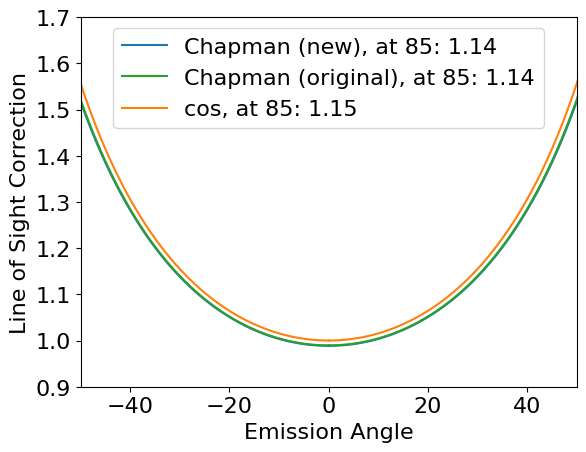

In [175]:


plt.axvline(x = 85, linewidth = 0.6, linestyle = "--", color = "black")
plt.axvline(x = -85, linewidth = 0.6, linestyle = "--", color = "black")

#current version
plt.plot(chiP_list,ch_list, label = "Chapman (new), at 85: " + str(round(ch_list[30],2)), c="tab:blue")
plt.plot(-1*np.asarray(chiP_list),ch_list, c="tab:blue")

#original
plt.plot(chiP_list,chapman_og[1], label = "Chapman (original), at 85: " + str(round(chapman_og[1][30],2)), c="tab:green")
plt.plot(-1*np.asarray(chiP_list),chapman_og[1], c="tab:green")

#cos
plt.plot(chiP_list, 1/np.cos(np.radians(np.asarray(chiP_list))), \
         label = "cos, at 85: " + str(round(1/np.cos(np.radians(np.asarray(chiP_list[30]))),2)), c="tab:orange")
plt.plot(-1*np.asarray(chiP_list),1/np.cos(np.radians(np.asarray(chiP_list))), c="tab:orange")



plt.xlabel("Emission Angle")
plt.ylabel("Line of Sight Correction") #(Chapman's Grazing Incidence Integral Approximation)
plt.ylim(0.9,1.7)
plt.xlim(-50,50)
plt.legend(loc = "upper center")
plt.show()

In [152]:
np.max(np.abs(chapman_og[1][0:50] - ch_list[0:50])*100)

0.4323195105739419

In [153]:
np.max(np.abs(1/np.cos(np.radians(np.asarray(chiP_list)))[0:50] - ch_list[0:50])*100)

3.6891521243792136

In [154]:
np.abs(chapman_og[1][60:80] - ch_list[60:80]*100)

8.028378001566061

In [216]:
num = 60

print(str(round(np.abs(chapman_og[1][num] - ch_list[num])/ch_list[num]*100,2)) + "% difference")

print("Factor of " + str(round(chapman_og[1][num]/ch_list[num],2)))

0.49% difference
Factor of 1.0


In [217]:

num = 60

print(str(round(np.abs(1/np.cos(np.radians(np.asarray(chiP_list)))[num] - ch_list[num])/ch_list[num]*100,2)) + "% difference")

print("Factor of " + str(round(np.abs(1/np.cos(np.radians(np.asarray(chiP_list)))[num])/ch_list[num],2)))

4.21% difference
Factor of 1.04
